# Figure 9 — Mouse vs. marmoset, 80-20 only

**REBUILT (2026-09-18)** per direct user feedback that the earlier
state-color/species-marker, multi-condition design ("this figure is
horrific") didn't work. This version is styled directly after Fig 8's own
panel design (`fig8.py`) instead:

- **a** — p(high-prob choice) aligned to block reversal (left) + per-subject
  mean session accuracy (right), marmoset vs. mouse
- **b** — p(switch) aligned to block reversal (left) + per-subject mean
  switch rate (right), marmoset vs. mouse
- **params** — sticky Q-learning model parameters (alpha/beta/kappa),
  marmoset vs. mouse, at 80-20 only
- **states** — proportion of trials in each behavioral state, marmoset vs.
  mouse, at 80-20 only (one small panel per state) -- direct analogue of
  Fig 8 panel c, just marmoset-vs-mouse instead of 80-20-vs-100-0

**Why 80-20 only:** it's the one condition both species' task design
shares most directly (marmoset: 80-20/90-10/100-0 Reversal task; mouse:
70-30/80-20/90-10, Beron et al. bandit data). A direct, classifier-free
comparison at this condition already showed mice have real, significantly
higher accuracy and lower switch rates than marmosets here (not a
classifier artifact) -- so this figure asks a single, focused question at
one condition rather than trying to force a multi-condition gradient
comparison across species with different task designs.

**Threshold sets:** each species is classified against its OWN
K-means-derived thresholds (marmoset: `marmoset`; mouse:
`mouse_calibrated`, from `derive_mouse_thresholds.py`) -- not one
species' thresholds applied to both. See `config.yaml`'s `fig9` section
for the full account.

**No pairing between species:** unlike Fig 8's paired comparison (the SAME
5 marmosets across 2 conditions), mouse and marmoset here are different
individuals of different species -- every scatter below is unpaired
(jittered dot clouds, no connecting lines), and every significance test is
an unpaired t-test (`scipy.stats.ttest_ind`), not Fig 8's paired one.

In [1]:
import os
import sys
import json
import functools

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import SVG, display

sys.path.insert(0, os.path.abspath(".."))

from src.io.load_snapshots import load_config
from src.behavior_metrics import reversal_alignment as ra
from src.plotting.style import apply_style
from src.plotting import fig9 as plotting

config = load_config()
apply_style(config)
cfg = config["fig9"]

CROSS_SPECIES_DIR = os.path.normpath(os.path.join(os.path.abspath(".."), cfg["cross_species_dir"]))
MARMOSET_THRESH_DIR = os.path.join(CROSS_SPECIES_DIR, "outputs", f"{cfg['marmoset_threshold_set']}_thresholds")
MOUSE_THRESH_DIR = os.path.join(CROSS_SPECIES_DIR, "outputs", f"{cfg['mouse_threshold_set']}_thresholds")
print(f"Reading marmoset outputs from: {MARMOSET_THRESH_DIR}")
print(f"Reading mouse outputs from:    {MOUSE_THRESH_DIR}")

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig9")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "Fig 9 -- mouse vs marmoset, 80-20 only, Fig-8-styled rebuild"}

def show(path):
    display(SVG(path))

COND = cfg["performance_condition"]  # "80-20"

marmoset = pd.read_csv(os.path.join(MARMOSET_THRESH_DIR, "marmoset_df_classified.csv"), low_memory=False)
marmoset = marmoset[(marmoset["prob_Condition"] == COND) & (marmoset["Behavioral_State"] != "Unknown")].reset_index(drop=True)

mouse = pd.read_csv(os.path.join(MOUSE_THRESH_DIR, "df_classified.csv"), low_memory=False)
mouse = mouse[(mouse["Condition"] == COND) & (mouse["Behavioral_State"] != "Unknown")].reset_index(drop=True)
# Rename to marmoset-style column names -- reversal_alignment.py's
# accuracy_by_position_relative_to_transition hardcodes Session_ID/Trial,
# same rename pattern already used elsewhere in this project for the mouse
# side (e.g. run_pipeline_marmoset.py's df_for_wsls).
mouse = mouse.rename(columns={"Session": "Session_ID", "Mouse": "Animal_Name", "block_id": "BlockCount"})

print(f"marmoset @ {COND}: {len(marmoset):,} trials, {marmoset['Animal_Name'].nunique()} animals")
print(f"mouse @ {COND}:    {len(mouse):,} trials, {mouse['Animal_Name'].nunique()} mice")

Reading marmoset outputs from: /Users/kevinmastro/Documents/Github/marmoset_decision_making/cross_species_comparison/outputs/marmoset_thresholds
Reading mouse outputs from:    /Users/kevinmastro/Documents/Github/marmoset_decision_making/cross_species_comparison/outputs/mouse_calibrated_thresholds
marmoset @ 80-20: 62,453 trials, 5 animals
mouse @ 80-20:    117,016 trials, 6 mice


## Panel a — reversal-aligned accuracy + accuracy comparison

marmoset transitions: 3041 (5 animals)
mouse transitions:    2296 (6 mice)
Accuracy @ 80-20: marmoset=0.688+/-0.002  mouse=0.828+/-0.005  t=-22.611 p=3.069e-09


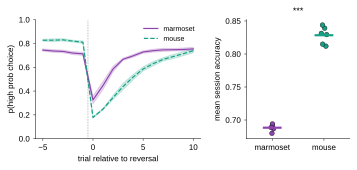

In [2]:
def build_transitions(df, session_col="Session_ID", block_col="BlockCount", animal_col="Animal_Name"):
    """One row per genuine block transition (excludes each session's own
    opening block, same convention as Fig 8's block_labels tables)."""
    d = df.sort_values([animal_col, session_col, "Trial"]).reset_index(drop=True)
    min_block = d.groupby(session_col)[block_col].transform("min")
    first_trial_mask = d["Trials_Since_Transition"] == 0
    trans = d[first_trial_mask & (d[block_col] != min_block)]
    return trans[[session_col, block_col, animal_col]].rename(
        columns={session_col: "session_id", block_col: "to_block", animal_col: "animal"}
    )

def position_summary(df, transitions, value_col, pre=5, post=10):
    aligned = ra.accuracy_by_position_relative_to_transition(df, transitions, value_col, pre, post, block_col="BlockCount")
    per_animal = aligned.groupby(["position", "animal"])["accuracy"].mean().reset_index()
    summary = per_animal.groupby("position")["accuracy"].agg(
        mean="mean", sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan, n="count"
    ).reset_index()
    return per_animal, summary

marm_trans = build_transitions(marmoset)
mouse_trans = build_transitions(mouse)
print(f"marmoset transitions: {len(marm_trans)} ({marm_trans['animal'].nunique()} animals)")
print(f"mouse transitions:    {len(mouse_trans)} ({mouse_trans['animal'].nunique()} mice)")

_, marm_pos_summary_acc = position_summary(marmoset, marm_trans, "High_Prob")
_, mouse_pos_summary_acc = position_summary(mouse, mouse_trans, "High_Prob")

def per_subject_performance(df, animal_col="Animal_Name", min_trials=30):
    """min_trials excludes a subject with too few trials at this
    condition to give a stable rate estimate -- found necessary directly:
    one marmoset (Coral) has exactly 1 trial at 90-10, giving a degenerate
    switch_rate/accuracy of 1.0 that skewed the whole comparison until
    this filter was added. Same convention as cross_condition.py's own
    len(sdf) < 30 gate elsewhere in this project."""
    summary = df.groupby(animal_col).agg(
        accuracy=("High_Prob", "mean"), switch_rate=("PhysicalSwitch", "mean"), n_trials=("High_Prob", "size")
    ).reset_index()
    dropped = summary[summary["n_trials"] < min_trials]
    if len(dropped):
        print(f"  per_subject_performance: dropping {len(dropped)} subject(s) with < {min_trials} trials: "
              f"{dict(zip(dropped[animal_col], dropped['n_trials']))}")
    return summary[summary["n_trials"] >= min_trials].reset_index(drop=True)

marm_perf = per_subject_performance(marmoset)
mouse_perf = per_subject_performance(mouse)

t_acc, p_acc = stats.ttest_ind(marm_perf["accuracy"], mouse_perf["accuracy"])
acc_ttest = {"t": float(t_acc), "p": float(p_acc)}
print(f"Accuracy @ {COND}: marmoset={marm_perf['accuracy'].mean():.3f}+/-{marm_perf['accuracy'].sem():.3f}  "
      f"mouse={mouse_perf['accuracy'].mean():.3f}+/-{mouse_perf['accuracy'].sem():.3f}  "
      f"t={t_acc:.3f} p={p_acc:.4g}")

manifest["panel_a_marmoset_pos_summary"] = marm_pos_summary_acc.to_dict(orient="records")
manifest["panel_a_mouse_pos_summary"] = mouse_pos_summary_acc.to_dict(orient="records")
manifest["panel_a_marmoset_perf"] = marm_perf.to_dict(orient="records")
manifest["panel_a_mouse_perf"] = mouse_perf.to_dict(orient="records")
manifest["panel_a_accuracy_ttest"] = acc_ttest

out_a = os.path.join(FIG_DIR, "Fig9a_accuracy.svg")
plotting.plot_panel_a(marm_pos_summary_acc, mouse_pos_summary_acc, marm_perf, mouse_perf, acc_ttest, out_a)
show(out_a)

## Panel b — reversal-aligned switch rate + switch-rate comparison

Switch rate @ 80-20: marmoset=0.197+/-0.016  mouse=0.066+/-0.008  t=7.732 p=2.902e-05


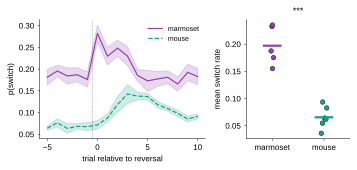

In [3]:
_, marm_pos_summary_switch = position_summary(marmoset, marm_trans, "PhysicalSwitch")
_, mouse_pos_summary_switch = position_summary(mouse, mouse_trans, "PhysicalSwitch")

t_sw, p_sw = stats.ttest_ind(marm_perf["switch_rate"], mouse_perf["switch_rate"])
switch_ttest = {"t": float(t_sw), "p": float(p_sw)}
print(f"Switch rate @ {COND}: marmoset={marm_perf['switch_rate'].mean():.3f}+/-{marm_perf['switch_rate'].sem():.3f}  "
      f"mouse={mouse_perf['switch_rate'].mean():.3f}+/-{mouse_perf['switch_rate'].sem():.3f}  "
      f"t={t_sw:.3f} p={p_sw:.4g}")

manifest["panel_b_marmoset_pos_summary"] = marm_pos_summary_switch.to_dict(orient="records")
manifest["panel_b_mouse_pos_summary"] = mouse_pos_summary_switch.to_dict(orient="records")
manifest["panel_b_switch_rate_ttest"] = switch_ttest

out_b = os.path.join(FIG_DIR, "Fig9b_switch_rate.svg")
plotting.plot_panel_b(marm_pos_summary_switch, mouse_pos_summary_switch, marm_perf, mouse_perf, switch_ttest, out_b)
show(out_b)

### Replication check — switch rate at 90-10

Same panel b design, at the OTHER condition both species share
(marmoset: 80-20/90-10/100-0; mouse: 70-30/80-20/90-10), to check the
80-20 switch-rate finding isn't specific to that one condition.

marmoset @ 90-10: 27,392 trials, 7 animals
mouse @ 90-10:    105,813 trials, 6 mice
  per_subject_performance: dropping 1 subject(s) with < 30 trials: {'Coral': 1}
Switch rate @ 90-10: marmoset=0.190+/-0.011  mouse=0.083+/-0.005  t=9.003 p=4.125e-06


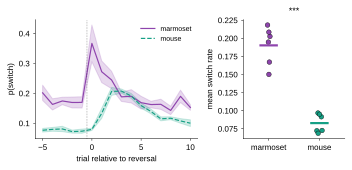

In [4]:
COND_90 = "90-10"

marmoset_90 = pd.read_csv(os.path.join(MARMOSET_THRESH_DIR, "marmoset_df_classified.csv"), low_memory=False)
marmoset_90 = marmoset_90[(marmoset_90["prob_Condition"] == COND_90) & (marmoset_90["Behavioral_State"] != "Unknown")].reset_index(drop=True)

mouse_90 = pd.read_csv(os.path.join(MOUSE_THRESH_DIR, "df_classified.csv"), low_memory=False)
mouse_90 = mouse_90[(mouse_90["Condition"] == COND_90) & (mouse_90["Behavioral_State"] != "Unknown")].reset_index(drop=True)
mouse_90 = mouse_90.rename(columns={"Session": "Session_ID", "Mouse": "Animal_Name", "block_id": "BlockCount"})

print(f"marmoset @ {COND_90}: {len(marmoset_90):,} trials, {marmoset_90['Animal_Name'].nunique()} animals")
print(f"mouse @ {COND_90}:    {len(mouse_90):,} trials, {mouse_90['Animal_Name'].nunique()} mice")

marm_trans_90 = build_transitions(marmoset_90)
mouse_trans_90 = build_transitions(mouse_90)

_, marm_pos_summary_switch_90 = position_summary(marmoset_90, marm_trans_90, "PhysicalSwitch")
_, mouse_pos_summary_switch_90 = position_summary(mouse_90, mouse_trans_90, "PhysicalSwitch")

marm_perf_90 = per_subject_performance(marmoset_90)
mouse_perf_90 = per_subject_performance(mouse_90)

t_sw_90, p_sw_90 = stats.ttest_ind(marm_perf_90["switch_rate"], mouse_perf_90["switch_rate"])
switch_ttest_90 = {"t": float(t_sw_90), "p": float(p_sw_90)}
print(f"Switch rate @ {COND_90}: marmoset={marm_perf_90['switch_rate'].mean():.3f}+/-{marm_perf_90['switch_rate'].sem():.3f}  "
      f"mouse={mouse_perf_90['switch_rate'].mean():.3f}+/-{mouse_perf_90['switch_rate'].sem():.3f}  "
      f"t={t_sw_90:.3f} p={p_sw_90:.4g}")

manifest["panel_b_90_10_marmoset_pos_summary"] = marm_pos_summary_switch_90.to_dict(orient="records")
manifest["panel_b_90_10_mouse_pos_summary"] = mouse_pos_summary_switch_90.to_dict(orient="records")
manifest["panel_b_90_10_marmoset_perf"] = marm_perf_90.to_dict(orient="records")
manifest["panel_b_90_10_mouse_perf"] = mouse_perf_90.to_dict(orient="records")
manifest["panel_b_90_10_switch_rate_ttest"] = switch_ttest_90

out_b_90 = os.path.join(FIG_DIR, "Fig9b_switch_rate_90-10.svg")
plotting.plot_panel_b(marm_pos_summary_switch_90, mouse_pos_summary_switch_90, marm_perf_90, mouse_perf_90, switch_ttest_90, out_b_90)
show(out_b_90)

## Panel — sticky Q-learning model parameters, 80-20 only

alpha: marmoset=0.728+/-0.048  mouse=0.529+/-0.035  t=3.427 p=0.007541
beta: marmoset=1.046+/-0.075  mouse=2.702+/-0.211  t=-6.818 p=7.745e-05
kappa: marmoset=1.307+/-0.167  mouse=1.818+/-0.113  t=-2.606 p=0.02844


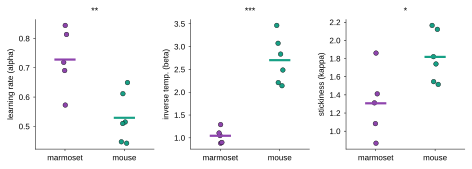

In [5]:
marm_fits = pd.read_csv(os.path.join(MARMOSET_THRESH_DIR, "marmoset_sticky_model_params_by_animal_by_condition.csv"))
mouse_fits = pd.read_csv(os.path.join(MOUSE_THRESH_DIR, "sticky_model_params_by_mouse_by_condition.csv"))
marm_fits_80_20 = marm_fits[marm_fits["Condition"] == COND]
mouse_fits_80_20 = mouse_fits[mouse_fits["Condition"] == COND]

param_results = {}
for param in ("alpha", "beta", "kappa"):
    mv = marm_fits_80_20[param].values
    ms = mouse_fits_80_20[param].values
    t, p = stats.ttest_ind(mv, ms)
    param_results[param] = {"marmoset_values": mv.tolist(), "mouse_values": ms.tolist(), "t": float(t), "p": float(p)}
    print(f"{param}: marmoset={mv.mean():.3f}+/-{mv.std(ddof=1)/np.sqrt(len(mv)):.3f}  "
          f"mouse={ms.mean():.3f}+/-{ms.std(ddof=1)/np.sqrt(len(ms)):.3f}  t={t:.3f} p={p:.4g}")

manifest["panel_params_80_20"] = param_results

out_params = os.path.join(FIG_DIR, "Fig9_params_80-20.svg")
plotting.plot_panel_params_80_20(param_results, out_params)
show(out_params)

## Panel — behavioral state proportions, 80-20 only

Exploitation          : marmoset=0.432  mouse=0.690  t=-12.979  p=3.937e-07
Directed Exploration  : marmoset=0.297  mouse=0.121  t=6.775  p=8.127e-05
Random Exploration    : marmoset=0.064  mouse=0.043  t=4.917  p=0.0008276
Left Bias             : marmoset=0.104  mouse=0.067  t=1.849  p=0.09757
Right Bias            : marmoset=0.098  mouse=0.076  t=1.758  p=0.1127


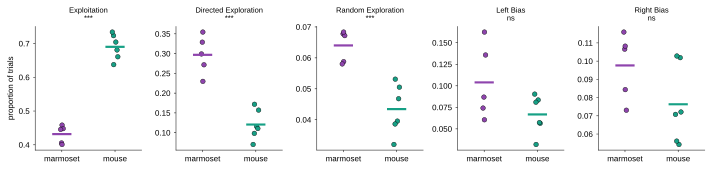

In [6]:
marm_prop_by_animal = pd.read_csv(os.path.join(MARMOSET_THRESH_DIR, "marmoset_state_proportions_by_condition_and_animal.csv"))
marm_prop_80_20 = marm_prop_by_animal[(marm_prop_by_animal["Condition"] == COND) & (marm_prop_by_animal["Behavioral_State"] != "Unknown")]

mouse_prop_by_mouse = pd.read_csv(os.path.join(MOUSE_THRESH_DIR, "state_proportions_by_condition_and_mouse.csv"))
mouse_prop_80_20 = mouse_prop_by_mouse[(mouse_prop_by_mouse["Condition"] == COND) & (mouse_prop_by_mouse["Behavioral_State"] != "Unknown")]

proportions_result = {}
for state in cfg["states_order"]:
    mv = marm_prop_80_20[marm_prop_80_20["Behavioral_State"] == state]["proportion"].values
    ms = mouse_prop_80_20[mouse_prop_80_20["Behavioral_State"] == state]["proportion"].values
    if len(mv) < 2 or len(ms) < 2:
        continue
    t, p = stats.ttest_ind(mv, ms)
    proportions_result[state] = {"marmoset_values": mv.tolist(), "mouse_values": ms.tolist(), "t": float(t), "p": float(p)}
    print(f"{state:22s}: marmoset={mv.mean():.3f}  mouse={ms.mean():.3f}  t={t:.3f}  p={p:.4g}")

manifest["panel_states_80_20"] = proportions_result

out_states = os.path.join(FIG_DIR, "Fig9_states_80-20.svg")
plotting.plot_panel_states_80_20(proportions_result, cfg["states_order"], out_states)
show(out_states)

## Values manifest

In [7]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig9.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"Saved values manifest: {manifest_path}")

Saved values manifest: ../outputs/values_manifests/Fig9.json
